# Finite-sample lemma validation for the analytic NTK on $S^1$

## Goal of the experiment

This experiment is designed to numerically validate the three finite-sample lemmas for uniformly sampled points on the circle $S^1$, using the analytic infinite-width kernel on the circle, and then to check their dynamical consequence for kernel gradient descent.

The primary purpose is **lemma verification**, not realism. For that reason, the main source of randomness is the sampled training points, not the initialization. We therefore use **zero initialization** in the main experiment.

---

## Mathematical setup

We parameterize the circle by an angle $\gamma \in [0,2\pi)$ and embed it as
$$
x(\gamma) = (\cos \gamma,\sin \gamma).
$$

For each run, we sample training angles
$$
\phi_1,\dots,\phi_n \overset{iid}{\sim} \mathrm{Unif}[0,2\pi).
$$

We then evaluate the target function on these sampled points. The target is a low-frequency Fourier mixture of the form
$$
f^*(\gamma) = 1 + 0.9\cos(\gamma) + 0.5\cos(2\gamma) + 0.35\cos(3\gamma).
$$

The kernel matrix is built from the analytic circle kernel:
$$
K_{ij} = \Theta(\phi_i,\phi_j),
$$
and the empirical operator is the normalized matrix
$$
A = \frac{1}{n}K.
$$

This normalization is important because the continuum operator is an average / integral operator, so $A$ is the discrete object on the same scale as the continuum limit.

---

## Fourier basis used in the lemmas

To probe low-frequency structure, we build the real Fourier basis up to frequency $K_{\max}$:
$$
\phi_0(\gamma)=1,
$$
$$
\phi_{k,c}(\gamma)=\sqrt{2}\cos(k\gamma), \qquad
\phi_{k,s}(\gamma)=\sqrt{2}\sin(k\gamma),
\qquad k=1,\dots,K_{\max}.
$$

Evaluating these basis functions on the sampled training angles gives the matrix
$$
\Phi \in \mathbb{R}^{n\times d},
$$
where $d=2K_{\max}+1$.

We then form the sampled Gram matrix
$$
G = \frac{1}{n}\Phi^\top \Phi,
$$
the compressed operator
$$
H = \frac{1}{n}\Phi^\top A \Phi,
$$
and the finite-$n$ diagonal benchmark
$$
\Lambda^{(n)} = \mathrm{diag}(\lambda_p^{(n)}),
\qquad
\lambda_p^{(n)} = \left(1-\frac{1}{n}\right)\lambda_p + \frac{1}{n}g(0),
$$
where $\lambda_p$ is the continuum eigenvalue associated with the corresponding Fourier mode, and $g(0)=\Theta(x,x)$ is the kernel value on the diagonal.

We also study the action error matrix
$$
E = A\Phi - \Phi\Lambda^{(n)}.
$$

---

## The three finite-sample questions

The experiment is built to answer the following three operator-level questions.

### 1. Gram concentration
Does the sampled Fourier basis remain approximately orthonormal?
$$
G = \frac{1}{n}\Phi^\top\Phi \approx I?
$$

### 2. Compressed operator concentration
Does the empirical operator, compressed onto the low-frequency Fourier basis, look approximately diagonal with the predicted entries?
$$
H = \frac{1}{n}\Phi^\top A\Phi \approx \Lambda^{(n)}?
$$

### 3. Approximate eigen-action
Does the empirical operator act on the sampled Fourier basis columns approximately like multiplication by the benchmark eigenvalues?
$$
A\Phi \approx \Phi\Lambda^{(n)}?
$$

These are measured both globally and mode-by-mode.

---

## Metrics recorded in each run

For each run, we save scalar matrix error summaries:

- Gram concentration:
  $$
  \|G-I\|_{\max}, \qquad \|G-I\|_F
  $$

- Compressed operator concentration:
  $$
  \|H-\Lambda^{(n)}\|_{\max}, \qquad \|H-\Lambda^{(n)}\|_F
  $$

- Approximate eigen-action:
  $$
  \|A\Phi-\Phi\Lambda^{(n)}\|_{\max}, \qquad \|A\Phi-\Phi\Lambda^{(n)}\|_F
  $$

We also save the per-mode relative action errors
$$
\frac{\|A\phi_p - \lambda_p^{(n)}\phi_p\|_2}{\|\phi_p\|_2}.
$$

Since the lemmas are concentration statements, these quantities are studied as functions of the sample size $n$, aggregated over multiple random seeds.

---

## Dynamics block

After computing the static operator objects, we run zero-initialized kernel gradient descent driven by the normalized empirical operator $A$.

The train residual is
$$
r_t = y_t - y^*,
$$
and the training dynamics are
$$
y_{t+1} = y_t - \eta A r_t,
\qquad
r_{t+1} = (I-\eta A)r_t.
$$

The step size is chosen on the operator scale as
$$
\eta = \frac{\eta_{\mathrm{scale}}}{\lambda_{\max}(A)}
$$
unless specified manually.

---

## Ideal mode-decay reference

To understand the dynamical consequence of the lemmas, we project the residual trajectory onto sampled low-frequency modes and compare the observed decay to the ideal diagonal prediction.

If $\alpha_p(t)$ denotes the coefficient of the residual along mode $p$, then the ideal reference is
$$
\alpha_p^{\mathrm{ideal}}(t)
=
(1-\eta\lambda_p^{(n)})^t \alpha_p(0).
$$

The main question here is:

> If the target lies mostly in low Fourier modes, does the observed sampled-mode decay track the ideal decay predicted by $\Lambda^{(n)}$?

---

## Dense-grid prediction probe

In addition to the operator-level diagnostics, we also evolve predictions on a dense deterministic grid on the circle. This grid is **not** a separate test set in the statistical sense. It is simply a probe grid used to visualize the learned function over the whole circle.

This lets us compare the final learned prediction
$$
\gamma \mapsto f_{\mathrm{pred}}(\gamma)
$$
against the target
$$
\gamma \mapsto f^*(\gamma)
$$
and connect the abstract operator diagnostics to an interpretable function-space picture.

---

## What we will analyze in this notebook

In this notebook, we will study:

1. how the three lemma error metrics change with $n$,
2. how much variability there is across random seeds,
3. how the per-mode action errors depend on mode index,
4. how closely observed low-mode residual decay matches the ideal decay predicted by $\Lambda^{(n)}$,
5. and what the final learned prediction function looks like on the dense circle grid.

The central empirical story is therefore:

- as $n$ increases, the sampled low-frequency Fourier geometry should become more continuum-like,
- the compressed operator should become more diagonal and closer to the benchmark spectrum,
- the sampled Fourier modes should behave more like approximate eigenfunctions,
- and consequently the residual dynamics along low modes should look increasingly close to the ideal diagonal decay law.

In [1]:
import os, sys
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print("Project root added to sys.path:", ROOT)

from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
import jax.numpy as jnp
from utils.artifacts_io import latest_run_dir, load_manifest, npz
from collections import defaultdict

Project root added to sys.path: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments


In [2]:
BASE = "../results"
EXP_NAME = "kernel_circle_lemma_validation_const_eta"

plot_path = Path("plots") / EXP_NAME
plot_path.mkdir(parents=True, exist_ok=True)
print("Plots will be saved to:", plot_path)

Plots will be saved to: plots/kernel_circle_lemma_validation_const_eta


In [3]:
run_dir = latest_run_dir(BASE, EXP_NAME)
if run_dir is None:
    raise FileNotFoundError(f"No run found for experiment '{EXP_NAME}' in {BASE}")

manifest = load_manifest(run_dir)
probe = npz(run_dir, manifest["probe_geometry"])

print("Loaded run dir:", run_dir)
print("Available run count:", len(manifest["runs"]))
print("n_trains:", manifest["meta"]["n_trains"])
print("seeds:", manifest["meta"]["seeds"])
print("K_max:", manifest["meta"]["K_max"])
print("kernel:", manifest["meta"]["kernel"])
print("steps:", manifest["meta"]["steps"])
print("eta_scale:", manifest["meta"]["eta_scale"])

Loaded run dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_circle_lemma_validation_const_eta/20260328-173834-59d51f6c
Available run count: 90
n_trains: [64, 128, 256, 512, 1024, 2048, 4096, 8192, 16384]
seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
K_max: 10
kernel: bias
steps: 2000
eta_scale: 0.05


In [4]:
runs = {}
for run_key, rel_path in manifest["runs"].items():
    runs[run_key] = npz(run_dir, rel_path)

print("Loaded per-run files:", len(runs))
list(runs.keys())[:5]

Loaded per-run files: 90


['size_64_seed_0',
 'size_64_seed_1',
 'size_64_seed_2',
 'size_64_seed_3',
 'size_64_seed_4']

In [5]:
def parse_run_key(run_key: str):
    # expected format: size_<n>_seed_<s>
    parts = run_key.split("_")
    n = int(parts[1])
    seed = int(parts[3])
    return n, seed


def unpack_run(run_key: str, arrs) -> dict:
    n, seed = parse_run_key(run_key)

    out = {
        "run_key": run_key,
        "n": n,
        "seed": seed,

        # geometry
        "gamma_train": arrs["gamma_train"],
        "X_train": arrs["X_train"],
        "y_train": arrs["y_train"],

        # basis / operator
        "Phi": arrs["Phi"],
        "A": arrs["A"],
        "G": arrs["G"],
        "H": arrs["H"],
        "Lambda_n_diag": arrs["Lambda_n_diag"],
        "mode_names": arrs["mode_names"],
        "mode_freqs": arrs["mode_freqs"],
        "mode_types": arrs["mode_types"],

        # lemma metrics
        "gram_err_max": float(np.asarray(arrs["gram_err_max"])),
        "gram_err_fro": float(np.asarray(arrs["gram_err_fro"])),
        "comp_err_max": float(np.asarray(arrs["comp_err_max"])),
        "comp_err_fro": float(np.asarray(arrs["comp_err_fro"])),
        "action_err_max": float(np.asarray(arrs["action_err_max"])),
        "action_err_fro": float(np.asarray(arrs["action_err_fro"])),
        "per_mode_action_relerr": arrs["per_mode_action_relerr"],

        # dynamics
        "y_pred_train": arrs["y_pred_train"],
        "r_train": arrs["r_train"],
        "loss": arrs["loss"],
        "eta": float(np.ravel(arrs["eta"])[0]),
        "snapshot_steps": arrs["snapshot_steps"],
        "y_pred_eval_snapshots": arrs["y_pred_eval_snapshots"],
        "y_pred_eval_final": arrs["y_pred_eval_final"],

        # decay diagnostics
        "mode_proj_train": arrs["mode_proj_train"],
        "mode_proj_train_ideal": arrs["mode_proj_train_ideal"],

        # metadata
        "g0": float(np.ravel(arrs["g0"])[0]),
        "lambda_max_A": float(np.ravel(arrs["lambda_max_A"])[0]),
    }
    return out


A = {run_key: unpack_run(run_key, arrs) for run_key, arrs in runs.items()}
print("Unpacked runs:", len(A))

Unpacked runs: 90


In [6]:
by_n = defaultdict(list)
for run_key, a in A.items():
    by_n[a["n"]].append(a)

for n in sorted(by_n):
    seeds = [x["seed"] for x in by_n[n]]
    print(f"n={n:4d}  runs={len(by_n[n])}  seeds={seeds}")

n=  64  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n= 128  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n= 256  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n= 512  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=1024  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=2048  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=4096  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=8192  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n=16384  runs=10  seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [7]:
def summarize_group(by_n_dict):
    print("=== Experiment summary ===")
    meta = manifest.get("meta", {})
    print("run_dir:", run_dir)
    print("kernel:", meta.get("kernel"))
    print("steps:", meta.get("steps"))
    print("eta_scale:", meta.get("eta_scale"))
    print("target_Ks:", meta.get("target_Ks"))
    print("target_amps:", meta.get("target_amps"))
    print("K_max:", meta.get("K_max"))
    print()

    for n in sorted(by_n_dict):
        runs_n = by_n_dict[n]
        eta_vals = [r["eta"] for r in runs_n]
        gram_vals = [r["gram_err_max"] for r in runs_n]
        comp_vals = [r["comp_err_max"] for r in runs_n]
        action_vals = [r["action_err_max"] for r in runs_n]

        print(f"n = {n}")
        print(f"  runs            : {len(runs_n)}")
        print(f"  eta mean        : {np.mean(eta_vals):.6f}")
        print(f"  gram_err_max    : mean={np.mean(gram_vals):.4e}, std={np.std(gram_vals):.4e}")
        print(f"  comp_err_max    : mean={np.mean(comp_vals):.4e}, std={np.std(comp_vals):.4e}")
        print(f"  action_err_max  : mean={np.mean(action_vals):.4e}, std={np.std(action_vals):.4e}")
        print()


summarize_group(by_n)

=== Experiment summary ===
run_dir: /Users/shreyas/Documents/msc-cs/msc-thesis/code/ntk-experiments/results/kernel_circle_lemma_validation_const_eta/20260328-173834-59d51f6c
kernel: bias
steps: 2000
eta_scale: 0.05
target_Ks: [0, 1, 2, 3]
target_amps: [1.0, 0.9, 0.5, 0.35]
K_max: 10

n = 64
  runs            : 10
  eta mean        : 0.080000
  gram_err_max    : mean=3.3554e-01, std=4.9902e-02
  comp_err_max    : mean=1.7919e-01, std=4.9015e-02
  action_err_max  : mean=2.3597e-01, std=4.3995e-02

n = 128
  runs            : 10
  eta mean        : 0.080000
  gram_err_max    : mean=2.3943e-01, std=3.1332e-02
  comp_err_max    : mean=1.2113e-01, std=1.8299e-02
  action_err_max  : mean=1.7554e-01, std=1.4709e-02

n = 256
  runs            : 10
  eta mean        : 0.080000
  gram_err_max    : mean=1.6678e-01, std=2.4223e-02
  comp_err_max    : mean=7.8159e-02, std=1.1556e-02
  action_err_max  : mean=1.1638e-01, std=1.2377e-02

n = 512
  runs            : 10
  eta mean        : 0.080000
  gra

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_gram_err_max.png


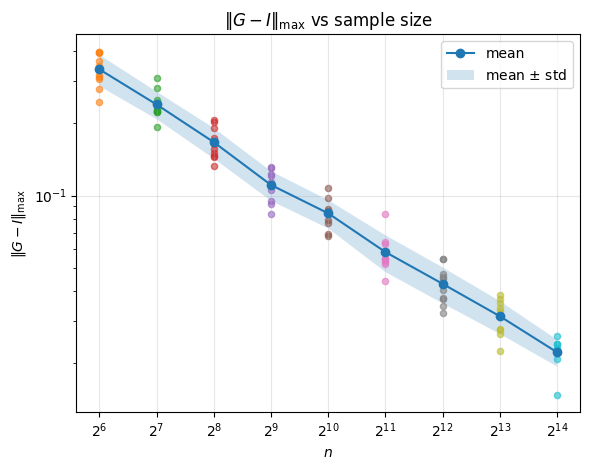

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_comp_err_max.png


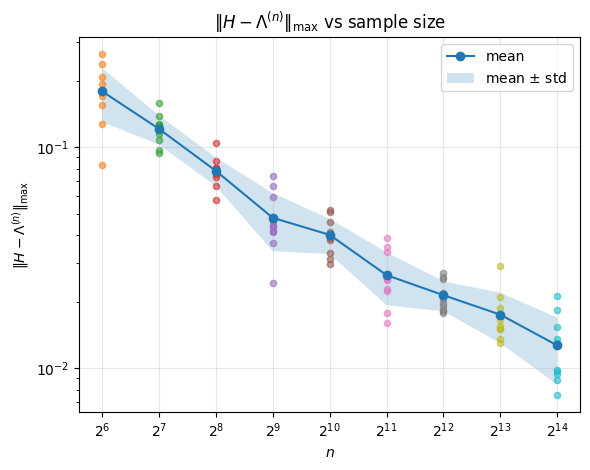

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_action_err_max.png


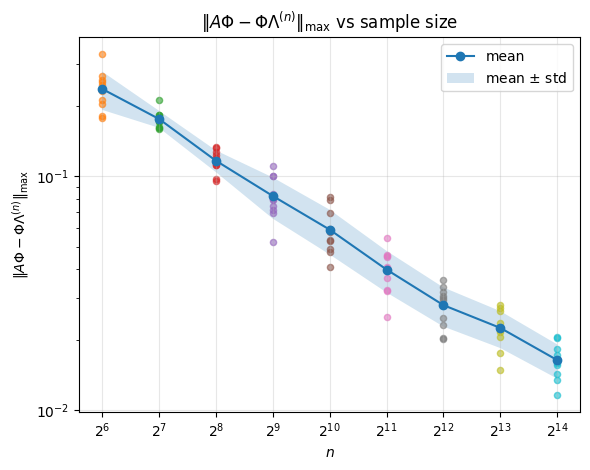

In [10]:
METRICS = [
    ("gram_err_max", r"$\|G-I\|_{\max}$"),
    ("comp_err_max", r"$\|H-\Lambda^{(n)}\|_{\max}$"),
    ("action_err_max", r"$\|A\Phi-\Phi\Lambda^{(n)}\|_{\max}$"),
]

def aggregate_metric_by_n(by_n, metric_name: str):
    ns = sorted(by_n.keys())
    means, stds, mins, maxs, all_vals = [], [], [], [], []

    for n in ns:
        vals = np.array([run[metric_name] for run in by_n[n]], dtype=float)
        means.append(vals.mean())
        stds.append(vals.std())
        mins.append(vals.min())
        maxs.append(vals.max())
        all_vals.append(vals)

    return {
        "ns": np.array(ns, dtype=int),
        "mean": np.array(means, dtype=float),
        "std": np.array(stds, dtype=float),
        "min": np.array(mins, dtype=float),
        "max": np.array(maxs, dtype=float),
        "all": all_vals,
    }

agg = {name: aggregate_metric_by_n(by_n, name) for name, _ in METRICS}

for metric_name, label in METRICS:
    # 1. Start a fresh, separate figure canvas
    plt.figure(figsize=(6, 4.8))
    
    d = agg[metric_name]
    ns = d["ns"]
    mean = d["mean"]
    std = d["std"]

    # 2. Make direct calls to plt.plot(), plt.scatter(), etc.
    plt.plot(ns, mean, marker="o", label="mean")
    plt.fill_between(ns, mean - std, mean + std, alpha=0.2, label=r"mean $\pm$ std")

    for i, n in enumerate(ns):
        plt.scatter(np.full_like(d["all"][i], n, dtype=float), d["all"][i], s=20, alpha=0.6)

    # 3. Format the plot
    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel(r"$n$")
    plt.ylabel(label)
    plt.title(f"{label} vs sample size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # 4. Save the plot individually (e.g., as a PNG file)
    filename = plot_path / f"concentration_plot_{metric_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Successfully saved {filename}")
    plt.show()

In [11]:
for metric_name, label in METRICS:
    d = agg[metric_name]
    print(f"\n=== {metric_name} ({label}) ===")
    for n, mean, std in zip(d["ns"], d["mean"], d["std"]):
        print(f"n={n:4d}   mean={mean:.4e}   std={std:.4e}")


=== gram_err_max ($\|G-I\|_{\max}$) ===
n=  64   mean=3.3554e-01   std=4.9902e-02
n= 128   mean=2.3943e-01   std=3.1332e-02
n= 256   mean=1.6678e-01   std=2.4223e-02
n= 512   mean=1.1063e-01   std=1.5631e-02
n=1024   mean=8.4298e-02   std=1.1365e-02
n=2048   mean=5.8129e-02   std=1.0147e-02
n=4096   mean=4.2856e-02   std=7.3185e-03
n=8192   mean=3.1401e-02   std=4.9009e-03
n=16384   mean=2.2224e-02   std=2.8415e-03

=== comp_err_max ($\|H-\Lambda^{(n)}\|_{\max}$) ===
n=  64   mean=1.7919e-01   std=4.9015e-02
n= 128   mean=1.2113e-01   std=1.8299e-02
n= 256   mean=7.8159e-02   std=1.1556e-02
n= 512   mean=4.7939e-02   std=1.4083e-02
n=1024   mean=4.0130e-02   std=7.2876e-03
n=2048   mean=2.6380e-02   std=7.0913e-03
n=4096   mean=2.1402e-02   std=3.3331e-03
n=8192   mean=1.7464e-02   std=4.4839e-03
n=16384   mean=1.2679e-02   std=4.2534e-03

=== action_err_max ($\|A\Phi-\Phi\Lambda^{(n)}\|_{\max}$) ===
n=  64   mean=2.3597e-01   std=4.3995e-02
n= 128   mean=1.7554e-01   std=1.4709e-02
n

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_gram_err_max.png


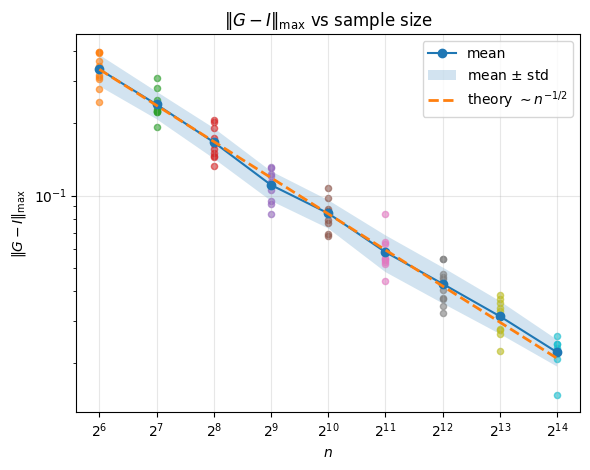

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_comp_err_max.png


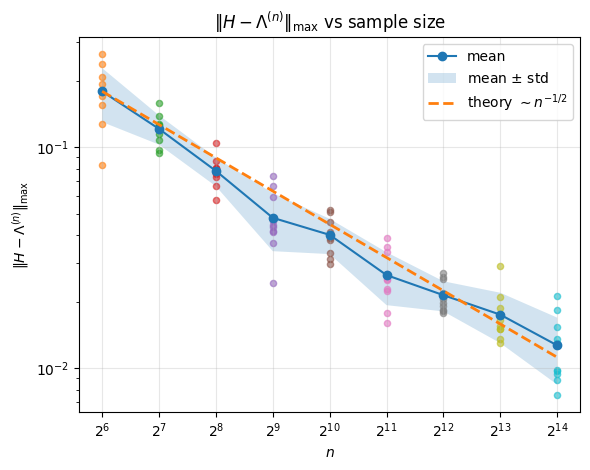

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_action_err_max.png


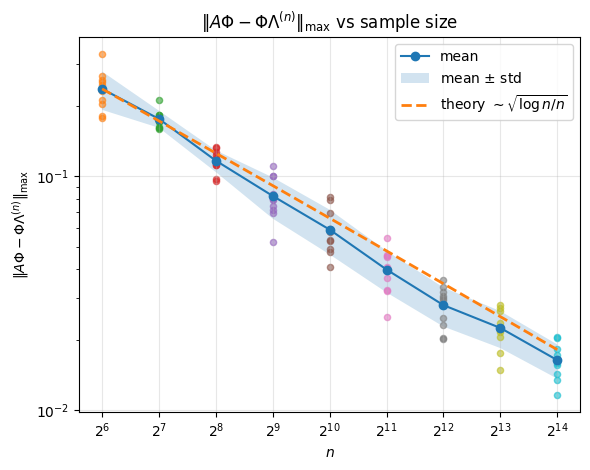

In [18]:
# Confidence level for the reference envelope
delta = 0.05

# Fixed Fourier block size
d = len(by_n[sorted(by_n.keys())[0]][0]["mode_names"])

# Bias-kernel sup norm
kappa = 1.5

def theory_gram(ns, d=d, delta=delta):
    return np.sqrt(8.0 * np.log(2.0 * d**2 / delta) / ns)

def theory_comp(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(32.0 * kappa**2 * np.log(2.0 * d**2 / delta) / ns)

def theory_action(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(4.0 * kappa**2 * np.log(2.0 * ns * d / delta) / ns)

THEORY = {
    "gram_err_max": (theory_gram, r"theory $\sim n^{-1/2}$"),
    "comp_err_max": (theory_comp, r"theory $\sim n^{-1/2}$"),
    "action_err_max": (theory_action, r"theory $\sim \sqrt{\log n / n}$"),
}

for metric_name, label in METRICS:
    plt.figure(figsize=(6, 4.8))

    d_agg = agg[metric_name]
    ns = d_agg["ns"].astype(float)
    mean = d_agg["mean"]
    std = d_agg["std"]

    plt.plot(ns, mean, marker="o", label="mean")
    plt.fill_between(ns, np.maximum(mean - std, 1e-16), mean + std, alpha=0.2, label=r"mean $\pm$ std")

    for i, n in enumerate(ns):
        plt.scatter(np.full_like(d_agg["all"][i], n, dtype=float), d_agg["all"][i], s=20, alpha=0.6)

    if metric_name in THEORY:
        theory_fn, theory_label = THEORY[metric_name]
        theory_vals = theory_fn(ns)

        # optional: rescale to match the first mean point visually
        scale = mean[0] / theory_vals[0]
        plt.plot(ns, scale * theory_vals, "--", linewidth=2, label=theory_label)

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel(r"$n$")
    plt.ylabel(label)
    plt.title(f"{label} vs sample size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = plot_path / f"concentration_plot_{metric_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Successfully saved {filename}")
    plt.show()

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_gram_err_max.png


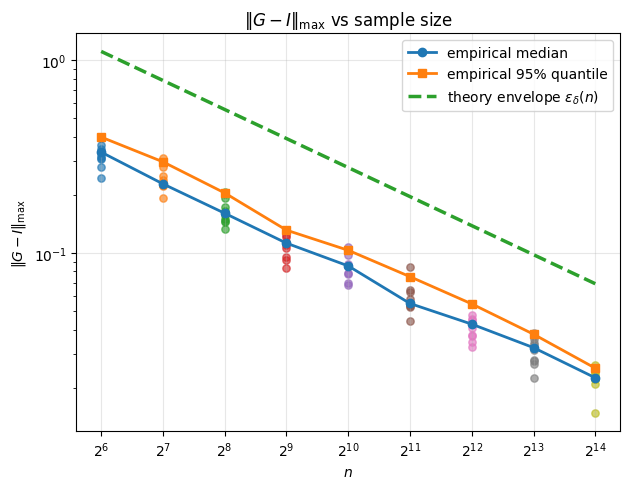

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_comp_err_max.png


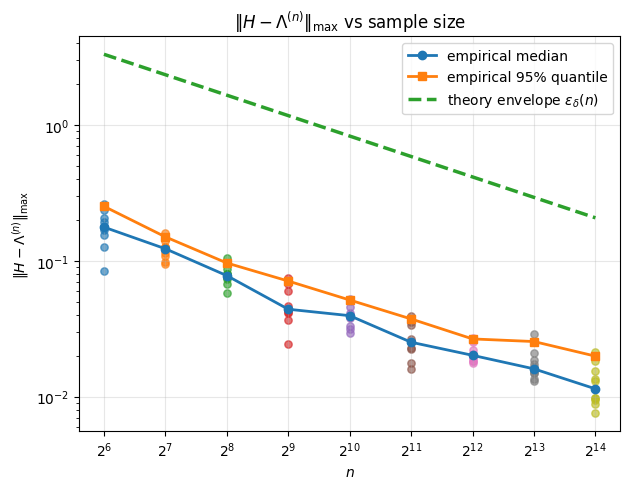

Successfully saved plots/kernel_circle_lemma_validation_const_eta/concentration_plot_action_err_max.png


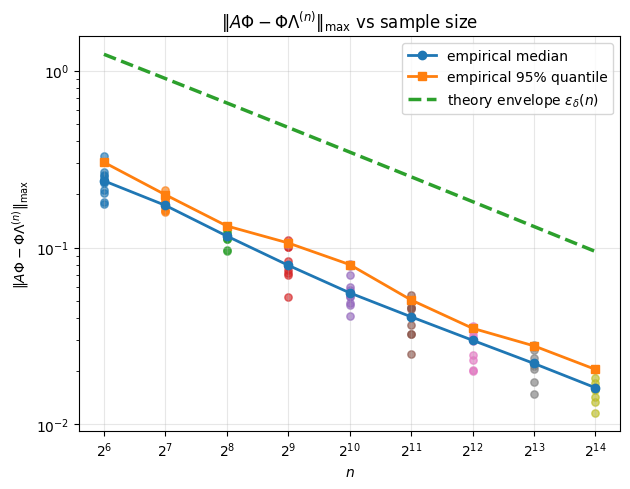

In [10]:
METRICS = [
    ("gram_err_max", r"$\|G-I\|_{\max}$"),
    ("comp_err_max", r"$\|H-\Lambda^{(n)}\|_{\max}$"),
    ("action_err_max", r"$\|A\Phi-\Phi\Lambda^{(n)}\|_{\max}$"),
]

def aggregate_metric_by_n(by_n, metric_name: str):
    ns = sorted(by_n.keys())
    means, stds, mins, maxs, all_vals = [], [], [], [], []

    for n in ns:
        vals = np.array([run[metric_name] for run in by_n[n]], dtype=float)
        means.append(vals.mean())
        stds.append(vals.std())
        mins.append(vals.min())
        maxs.append(vals.max())
        all_vals.append(vals)

    return {
        "ns": np.array(ns, dtype=int),
        "mean": np.array(means, dtype=float),
        "std": np.array(stds, dtype=float),
        "min": np.array(mins, dtype=float),
        "max": np.array(maxs, dtype=float),
        "all": all_vals,
    }

agg = {name: aggregate_metric_by_n(by_n, name) for name, _ in METRICS}

# Confidence level for the theoretical envelope
delta = 0.05

# Fixed Fourier block size
d = len(by_n[sorted(by_n.keys())[0]][0]["mode_names"])

# Bias-kernel sup norm
kappa = 1.5

def theory_gram(ns, d=d, delta=delta):
    return np.sqrt(8.0 * np.log(2.0 * d**2 / delta) / ns)

def theory_comp(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(32.0 * kappa**2 * np.log(2.0 * d**2 / delta) / ns)

def theory_action(ns, d=d, kappa=kappa, delta=delta):
    return np.sqrt(4.0 * kappa**2 * np.log(2.0 * ns * d / delta) / ns)

THEORY = {
    "gram_err_max": (theory_gram, r"theory envelope $\varepsilon_\delta(n)$"),
    "comp_err_max": (theory_comp, r"theory envelope $\varepsilon_\delta(n)$"),
    "action_err_max": (theory_action, r"theory envelope $\varepsilon_\delta(n)$"),
}

for metric_name, label in METRICS:
    plt.figure(figsize=(6.4, 5.0))

    d_agg = agg[metric_name]
    ns = d_agg["ns"].astype(float)

    # all_vals[i] = array of all seed values at ns[i]
    all_vals = d_agg["all"]

    # empirical (1-delta)-quantile
    q_emp = np.array([np.quantile(vals, 1.0 - delta) for vals in all_vals], dtype=float)
    med_emp = np.array([np.median(vals) for vals in all_vals], dtype=float)

    # raw seed scatter
    for i, n in enumerate(ns):
        vals = np.asarray(all_vals[i], dtype=float)
        plt.scatter(
            np.full_like(vals, n, dtype=float),
            vals,
            s=28,
            alpha=0.65,
        )

    # median and empirical quantile
    plt.plot(ns, med_emp, marker="o", linewidth=2, label="empirical median")
    plt.plot(ns, q_emp, marker="s", linewidth=2, label=fr"empirical {(1-delta):.0%} quantile")

    # exact theorem envelope: NO RESCALING
    theory_fn, theory_label = THEORY[metric_name]
    theory_vals = theory_fn(ns)
    plt.plot(ns, theory_vals, "--", linewidth=2.5, label=theory_label)

    plt.xscale("log", base=2)
    plt.yscale("log")
    plt.xlabel(r"$n$")
    plt.ylabel(label)
    plt.title(f"{label} vs sample size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    filename = plot_path / f"concentration_plot_{metric_name}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Successfully saved {filename}")
    plt.show()

In [11]:
for metric_name, label in METRICS:
    theory_fn, _ = THEORY[metric_name]
    d_agg = agg[metric_name]
    ns = d_agg["ns"].astype(float)
    theory_vals = theory_fn(ns)

    print(f"\n=== {metric_name} ({label}) ===")
    print("   n    theory_eps    exceedances / total    empirical_exceed_prob")
    for i, n in enumerate(ns):
        vals = np.asarray(d_agg["all"][i], dtype=float)
        eps = theory_vals[i]
        exc = np.sum(vals > eps)
        tot = len(vals)
        print(f"{int(n):5d}   {eps: .4e}         {exc:2d} / {tot:2d}             {exc/tot: .3f}")


=== gram_err_max ($\|G-I\|_{\max}$) ===
   n    theory_eps    exceedances / total    empirical_exceed_prob
   64    1.1055e+00          0 / 10              0.000
  128    7.8174e-01          0 / 10              0.000
  256    5.5277e-01          0 / 10              0.000
  512    3.9087e-01          0 / 10              0.000
 1024    2.7639e-01          0 / 10              0.000
 2048    1.9544e-01          0 / 10              0.000
 4096    1.3819e-01          0 / 10              0.000
 8192    9.7718e-02          0 / 10              0.000
16384    6.9097e-02          0 / 10              0.000

=== comp_err_max ($\|H-\Lambda^{(n)}\|_{\max}$) ===
   n    theory_eps    exceedances / total    empirical_exceed_prob
   64    3.3166e+00          0 / 10              0.000
  128    2.3452e+00          0 / 10              0.000
  256    1.6583e+00          0 / 10              0.000
  512    1.1726e+00          0 / 10              0.000
 1024    8.2916e-01          0 / 10              0.000
 2

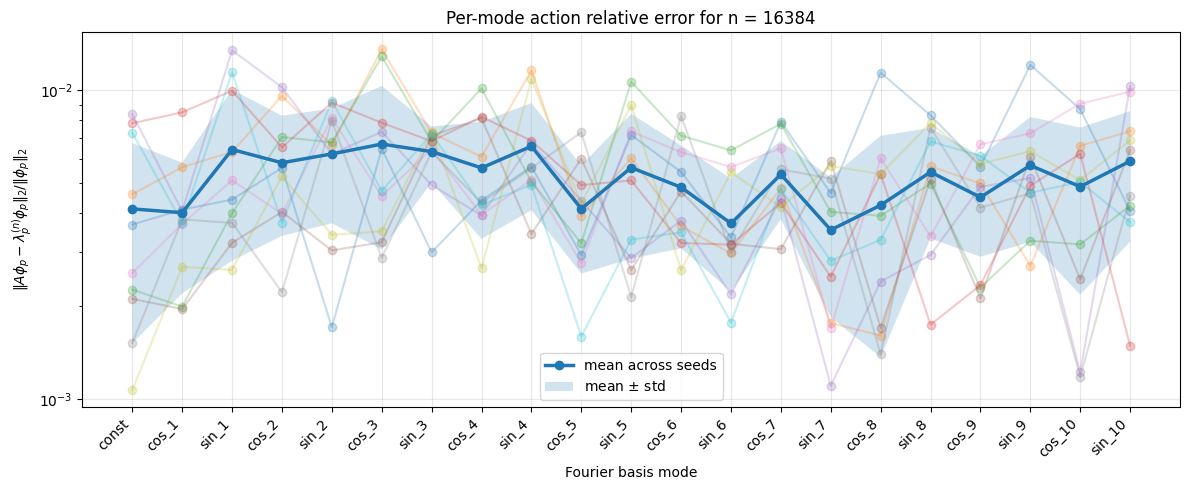

In [13]:
REP_N = max(by_n.keys())  # or set manually, e.g. 256 or 512

def decode_mode_names(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return out

runs_rep = by_n[REP_N]

mode_names = decode_mode_names(runs_rep[0]["mode_names"])
mode_freqs = np.asarray(runs_rep[0]["mode_freqs"])
per_seed = np.stack([np.asarray(r["per_mode_action_relerr"], dtype=float) for r in runs_rep], axis=0)

mean_relerr = per_seed.mean(axis=0)
std_relerr = per_seed.std(axis=0)

x = np.arange(len(mode_names))

plt.figure(figsize=(12, 5))

for row in per_seed:
    plt.plot(x, row, marker="o", alpha=0.25)

plt.plot(x, mean_relerr, marker="o", linewidth=2.5, label="mean across seeds")
plt.fill_between(
    x,
    np.maximum(mean_relerr - std_relerr, 0.0),
    mean_relerr + std_relerr,
    alpha=0.2,
    label=r"mean $\pm$ std",
)

plt.yscale("log")
plt.xticks(x, mode_names, rotation=45, ha="right")
plt.xlabel("Fourier basis mode")
plt.ylabel(r"$\|A\phi_p - \lambda_p^{(n)}\phi_p\|_2 / \|\phi_p\|_2$")
plt.title(f"Per-mode action relative error for n = {REP_N}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
print(f"=== Per-mode action relative error summary for n = {REP_N} ===")
for name, freq, m, s in zip(mode_names, mode_freqs, mean_relerr, std_relerr):
    print(f"{name:>8s}   freq={int(freq):2d}   mean={m:.4e}   std={s:.4e}")

=== Per-mode action relative error summary for n = 1024 ===
   const   freq= 0   mean=1.5680e-02   std=4.5349e-03
   cos_1   freq= 1   mean=2.0773e-02   std=6.2325e-03
   sin_1   freq= 1   mean=1.9359e-02   std=4.7971e-03
   cos_2   freq= 2   mean=2.1217e-02   std=1.1133e-02
   sin_2   freq= 2   mean=2.1351e-02   std=5.8136e-03
   cos_3   freq= 3   mean=2.1862e-02   std=7.3546e-03
   sin_3   freq= 3   mean=2.0923e-02   std=1.0896e-02
   cos_4   freq= 4   mean=1.6968e-02   std=9.0174e-03
   sin_4   freq= 4   mean=2.3292e-02   std=8.9375e-03
   cos_5   freq= 5   mean=2.1997e-02   std=1.0436e-02
   sin_5   freq= 5   mean=2.0870e-02   std=1.2369e-02
   cos_6   freq= 6   mean=2.1916e-02   std=8.7317e-03
   sin_6   freq= 6   mean=2.2864e-02   std=9.5576e-03
   cos_7   freq= 7   mean=2.5385e-02   std=1.1085e-02
   sin_7   freq= 7   mean=1.8125e-02   std=6.8686e-03
   cos_8   freq= 8   mean=1.8508e-02   std=7.9760e-03
   sin_8   freq= 8   mean=1.9327e-02   std=3.3421e-03
   cos_9   freq= 9   m

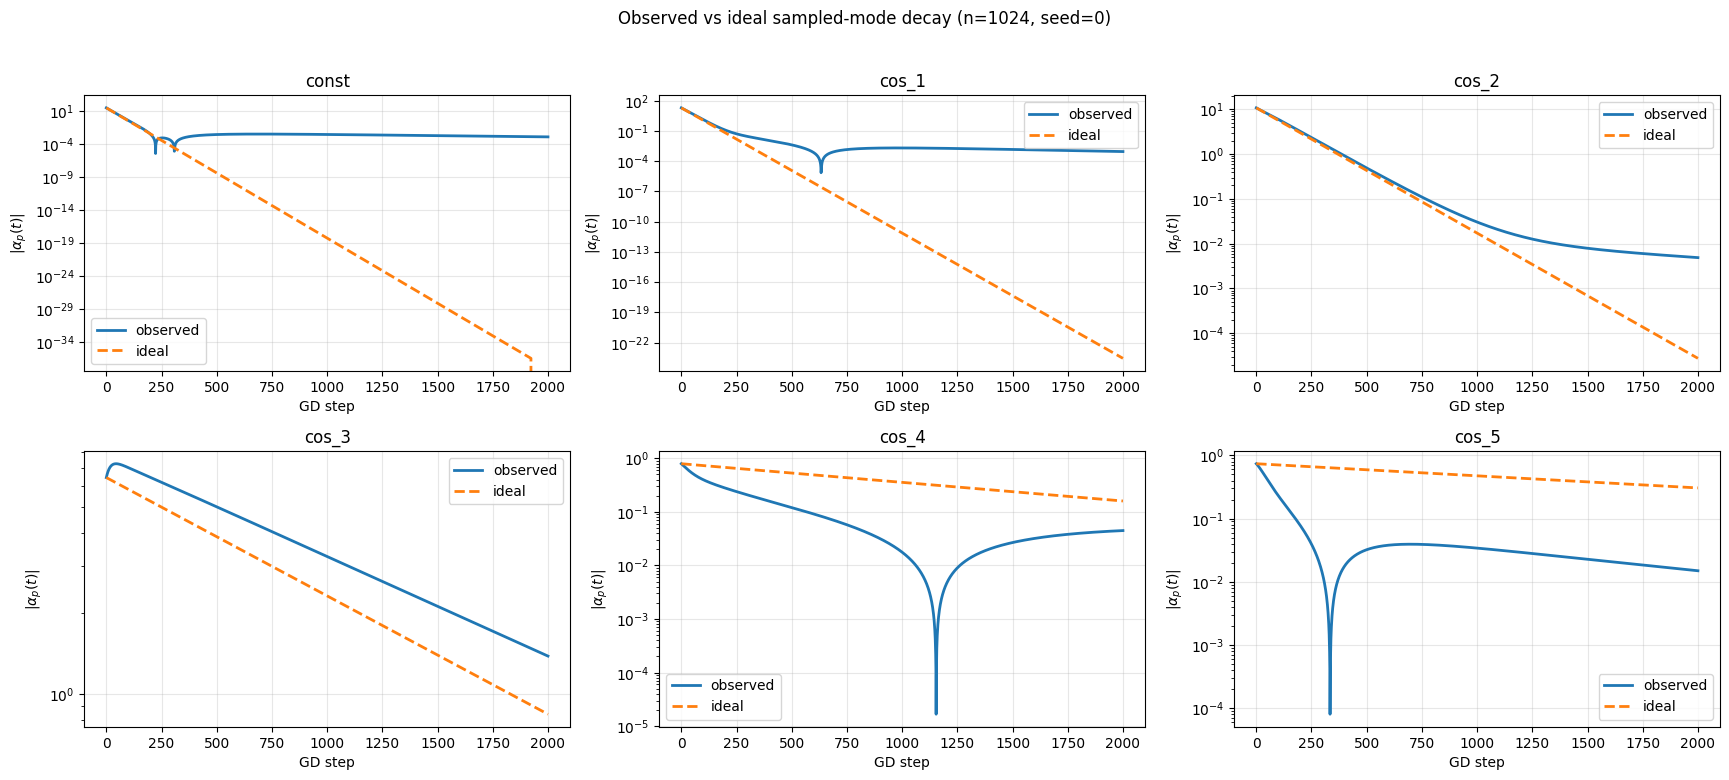

In [32]:
REP_N = max(by_n.keys())   # or set manually, e.g. 256 or 512
REP_SEED = by_n[REP_N][0]["seed"]  # or set manually

SELECT_MODES = ["const", "cos_1", "cos_2", "cos_3", "cos_4", "cos_5"]

def get_run_by_seed(runs_n, seed):
    for r in runs_n:
        if r["seed"] == seed:
            return r
    raise ValueError(f"Seed {seed} not found for n={runs_n[0]['n']}")

rep_run = get_run_by_seed(by_n[REP_N], REP_SEED)

mode_names = decode_mode_names(rep_run["mode_names"])
name_to_idx = {name: i for i, name in enumerate(mode_names)}

obs = np.asarray(rep_run["mode_proj_train"], dtype=float)         # [T, d]
ideal = np.asarray(rep_run["mode_proj_train_ideal"], dtype=float) # [T, d]
loss = np.asarray(rep_run["loss"], dtype=float)

T = obs.shape[0]
steps = np.arange(T)

selected = [m for m in SELECT_MODES if m in name_to_idx]
missing = [m for m in SELECT_MODES if m not in name_to_idx]
if missing:
    print("Skipping missing modes:", missing)

ncols = 3
nrows = int(np.ceil(len(selected) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.8 * ncols, 3.8 * nrows), squeeze=False)
axes = axes.ravel()

for ax, mode_name in zip(axes, selected):
    idx = name_to_idx[mode_name]

    y_obs = obs[:, idx]
    y_ideal = ideal[:, idx]

    ax.plot(steps, np.abs(y_obs), label="observed", linewidth=2)
    ax.plot(steps, np.abs(y_ideal), "--", label="ideal", linewidth=2)

    ax.set_yscale("log")
    ax.set_xlabel("GD step")
    ax.set_ylabel(r"$|\alpha_p(t)|$")
    ax.set_title(mode_name)
    ax.grid(True, alpha=0.3)
    ax.legend()

for ax in axes[len(selected):]:
    ax.axis("off")

plt.suptitle(f"Observed vs ideal sampled-mode decay (n={REP_N}, seed={REP_SEED})", y=1.02)
plt.tight_layout()
plt.show()

In [33]:
print(f"=== Initial sampled-mode coefficients: n={REP_N}, seed={REP_SEED} ===")
for mode_name in selected:
    idx = name_to_idx[mode_name]
    print(
        f"{mode_name:>8s}   "
        f"alpha_obs(0)={obs[0, idx]: .4e}   "
        f"alpha_ideal(0)={ideal[0, idx]: .4e}"
    )

=== Initial sampled-mode coefficients: n=1024, seed=0 ===
   const   alpha_obs(0)=-3.1174e+01   alpha_ideal(0)=-3.1174e+01
   cos_1   alpha_obs(0)=-1.8952e+01   alpha_ideal(0)=-1.8952e+01
   cos_2   alpha_obs(0)=-1.0759e+01   alpha_ideal(0)=-1.0759e+01
   cos_3   alpha_obs(0)=-6.4264e+00   alpha_ideal(0)=-6.4264e+00
   cos_4   alpha_obs(0)= 7.9264e-01   alpha_ideal(0)= 7.9264e-01
   cos_5   alpha_obs(0)= 7.3808e-01   alpha_ideal(0)= 7.3808e-01


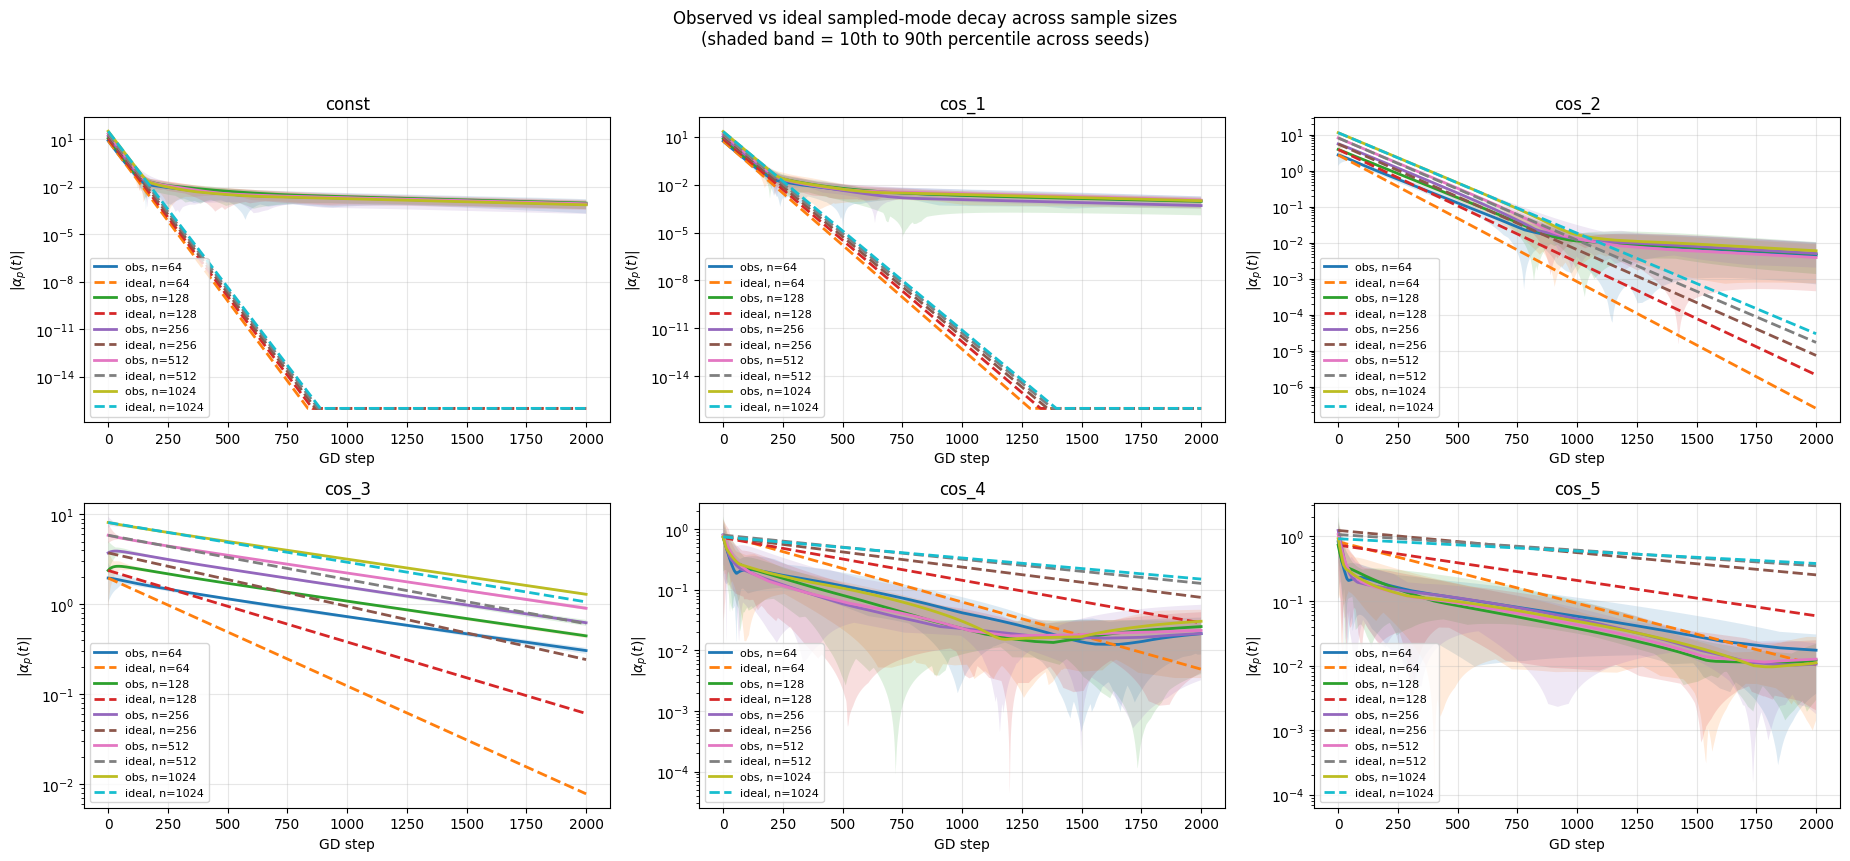

In [36]:
SELECT_MODES = ["const", "cos_1", "cos_2", "cos_3", "cos_4", "cos_5"]
EPS = 1e-16

# Use mode names from any representative run
some_n = sorted(by_n.keys())[0]
some_run = by_n[some_n][0]
mode_names = decode_mode_names(some_run["mode_names"])
name_to_idx = {name: i for i, name in enumerate(mode_names)}

selected = [m for m in SELECT_MODES if m in name_to_idx]
missing = [m for m in SELECT_MODES if m not in name_to_idx]
if missing:
    print("Skipping missing modes:", missing)

def aggregate_mode_decay(by_n, mode_name):
    idx = name_to_idx[mode_name]
    out = {}

    for n in sorted(by_n.keys()):
        obs_list = []
        ideal_list = []

        for r in by_n[n]:
            obs = np.abs(np.asarray(r["mode_proj_train"], dtype=float)[:, idx])
            ideal = np.abs(np.asarray(r["mode_proj_train_ideal"], dtype=float)[:, idx])

            obs_list.append(obs)
            ideal_list.append(ideal)

        obs_arr = np.stack(obs_list, axis=0)      # [num_seeds, T]
        ideal_arr = np.stack(ideal_list, axis=0)  # [num_seeds, T]

        out[n] = {
            "steps": np.arange(obs_arr.shape[1]),
            "obs_mean": obs_arr.mean(axis=0),
            "obs_std": obs_arr.std(axis=0),
            "obs_p10": np.percentile(obs_arr, 10, axis=0),
            "obs_p90": np.percentile(obs_arr, 90, axis=0),
            "ideal_mean": ideal_arr.mean(axis=0),
            "ideal_std": ideal_arr.std(axis=0),
            "ideal_p10": np.percentile(ideal_arr, 10, axis=0),
            "ideal_p90": np.percentile(ideal_arr, 90, axis=0),
        }

    return out

decay_summary = {mode: aggregate_mode_decay(by_n, mode) for mode in selected}

ncols = 3
nrows = int(np.ceil(len(selected) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6.2 * ncols, 4.2 * nrows), squeeze=False)
axes = axes.ravel()

for ax, mode_name in zip(axes, selected):
    summary = decay_summary[mode_name]

    for n in sorted(summary.keys()):
        d = summary[n]
        steps = d["steps"]

        obs_mean = np.maximum(d["obs_mean"], EPS)
        obs_lo = np.maximum(d["obs_p10"], EPS)
        obs_hi = np.maximum(d["obs_p90"], EPS)

        ideal_mean = np.maximum(d["ideal_mean"], EPS)

        ax.plot(
            steps,
            obs_mean,
            linewidth=2,
            label=f"obs, n={n}",
        )
        ax.fill_between(
            steps,
            obs_lo,
            obs_hi,
            alpha=0.15,
        )

        ax.plot(
            steps,
            ideal_mean,
            "--",
            linewidth=2,
            label=f"ideal, n={n}",
        )

    ax.set_yscale("log")
    ax.set_xlabel("GD step")
    ax.set_ylabel(r"$|\alpha_p(t)|$")
    ax.set_title(mode_name)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[len(selected):]:
    ax.axis("off")

plt.suptitle("Observed vs ideal sampled-mode decay across sample sizes\n(shaded band = 10th to 90th percentile across seeds)", y=1.02)
plt.tight_layout()
plt.show()

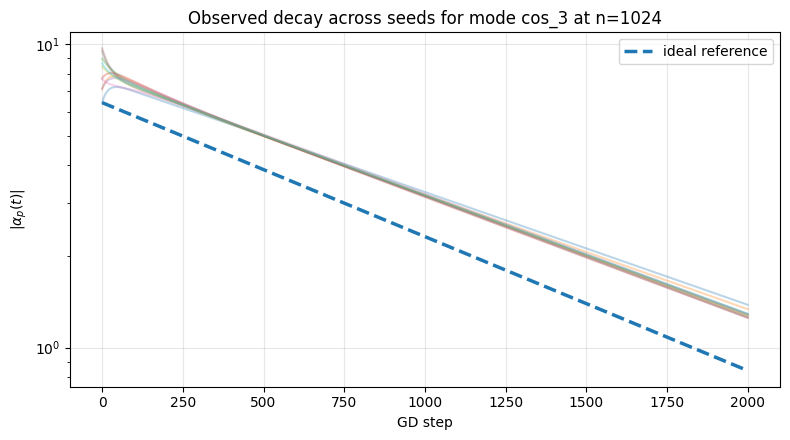

In [37]:
MODE_FOR_SEED_OVERLAY = "cos_3"

idx = name_to_idx[MODE_FOR_SEED_OVERLAY]

plt.figure(figsize=(8, 4.5))
for r in by_n[REP_N]:
    obs_r = np.asarray(r["mode_proj_train"], dtype=float)[:, idx]
    plt.plot(np.arange(len(obs_r)), np.abs(obs_r), alpha=0.3)

ideal_r = np.asarray(by_n[REP_N][0]["mode_proj_train_ideal"], dtype=float)[:, idx]
plt.plot(np.arange(len(ideal_r)), np.abs(ideal_r), "--", linewidth=2.5, label="ideal reference")

plt.yscale("log")
plt.xlabel("GD step")
plt.ylabel(r"$|\alpha_p(t)|$")
plt.title(f"Observed decay across seeds for mode {MODE_FOR_SEED_OVERLAY} at n={REP_N}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

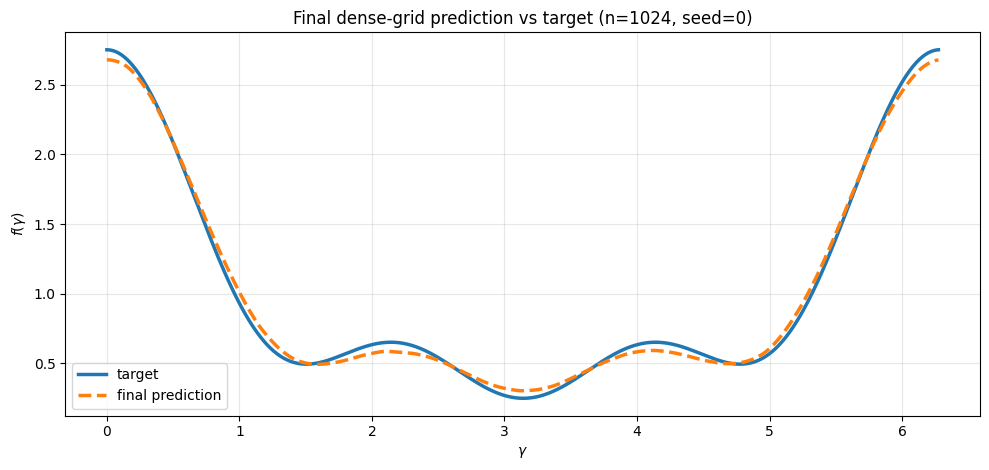

In [38]:
REP_N = max(by_n.keys())   # or set manually
REP_SEED = by_n[REP_N][0]["seed"]  # or set manually

rep_run = get_run_by_seed(by_n[REP_N], REP_SEED)

gamma_eval = np.asarray(probe["gamma_eval"], dtype=float)
y_eval = np.asarray(probe["y_eval"], dtype=float)
y_pred_eval_final = np.asarray(rep_run["y_pred_eval_final"], dtype=float)

order = np.argsort(gamma_eval)
gamma_plot = gamma_eval[order]
y_target_plot = y_eval[order]
y_pred_plot = y_pred_eval_final[order]

plt.figure(figsize=(10, 4.8))
plt.plot(gamma_plot, y_target_plot, label="target", linewidth=2.5)
plt.plot(gamma_plot, y_pred_plot, "--", label="final prediction", linewidth=2.5)

plt.xlabel(r"$\gamma$")
plt.ylabel(r"$f(\gamma)$")
plt.title(f"Final dense-grid prediction vs target (n={REP_N}, seed={REP_SEED})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

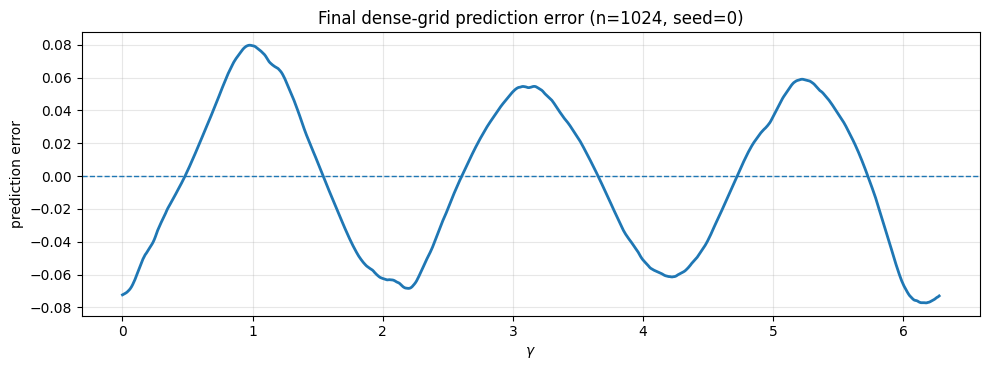

Relative L2 error on dense grid: 3.6757e-02


In [39]:
err_eval = y_pred_plot - y_target_plot

plt.figure(figsize=(10, 3.8))
plt.plot(gamma_plot, err_eval, linewidth=2)
plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel(r"$\gamma$")
plt.ylabel("prediction error")
plt.title(f"Final dense-grid prediction error (n={REP_N}, seed={REP_SEED})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rel_l2 = np.linalg.norm(err_eval) / (np.linalg.norm(y_target_plot) + 1e-12)
print(f"Relative L2 error on dense grid: {rel_l2:.4e}")

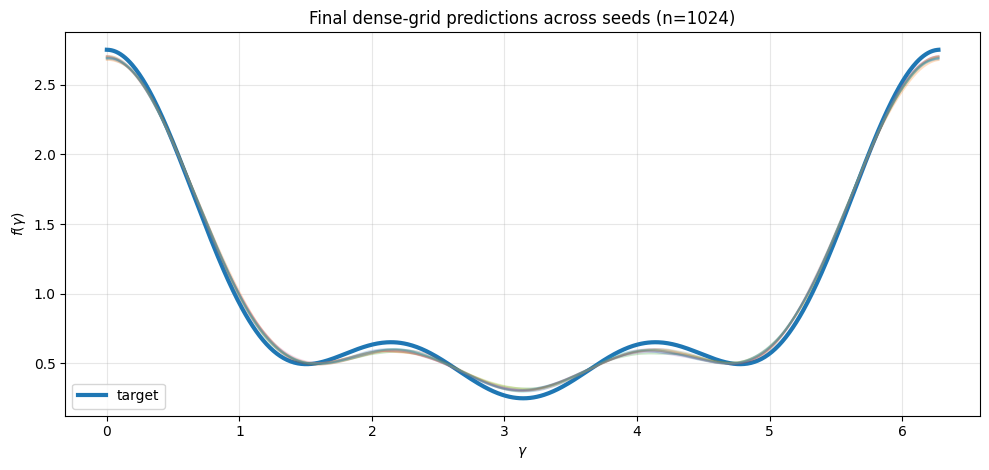

In [40]:
REP_N = max(by_n.keys())

plt.figure(figsize=(10, 4.8))
plt.plot(gamma_plot, y_target_plot, linewidth=3, label="target")

for r in by_n[REP_N]:
    y_pred = np.asarray(r["y_pred_eval_final"], dtype=float)[order]
    plt.plot(gamma_plot, y_pred, alpha=0.25)

plt.xlabel(r"$\gamma$")
plt.ylabel(r"$f(\gamma)$")
plt.title(f"Final dense-grid predictions across seeds (n={REP_N})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

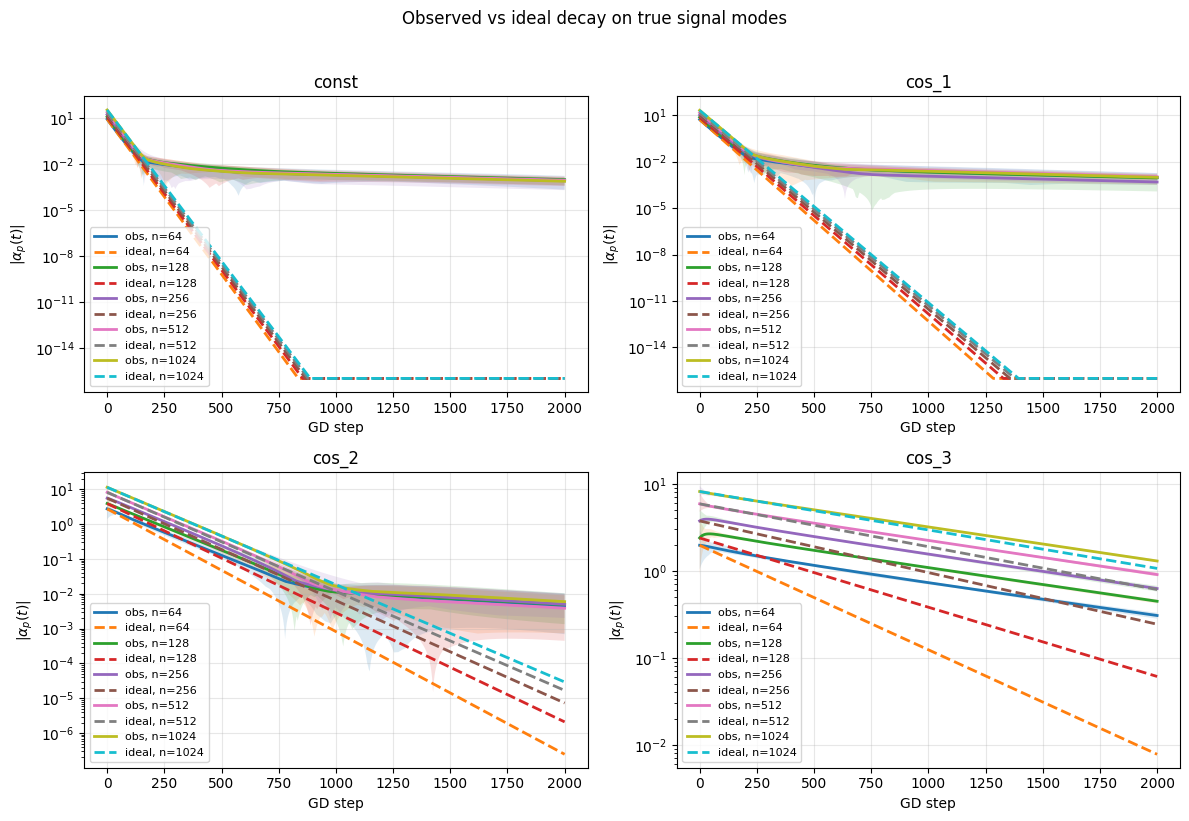

In [42]:
TRUE_SIGNAL_MODES = ["const", "cos_1", "cos_2", "cos_3"]
EPS = 1e-16

some_n = sorted(by_n.keys())[0]
some_run = by_n[some_n][0]
mode_names = decode_mode_names(some_run["mode_names"])
name_to_idx = {name: i for i, name in enumerate(mode_names)}

selected = [m for m in TRUE_SIGNAL_MODES if m in name_to_idx]

def aggregate_mode_decay(by_n, mode_name):
    idx = name_to_idx[mode_name]
    out = {}

    for n in sorted(by_n.keys()):
        obs_list = []
        ideal_list = []

        for r in by_n[n]:
            obs = np.abs(np.asarray(r["mode_proj_train"], dtype=float)[:, idx])
            ideal = np.abs(np.asarray(r["mode_proj_train_ideal"], dtype=float)[:, idx])

            obs_list.append(obs)
            ideal_list.append(ideal)

        obs_arr = np.stack(obs_list, axis=0)
        ideal_arr = np.stack(ideal_list, axis=0)

        out[n] = {
            "steps": np.arange(obs_arr.shape[1]),
            "obs_mean": obs_arr.mean(axis=0),
            "obs_p10": np.percentile(obs_arr, 10, axis=0),
            "obs_p90": np.percentile(obs_arr, 90, axis=0),
            "ideal_mean": ideal_arr.mean(axis=0),
        }

    return out

signal_decay_summary = {mode: aggregate_mode_decay(by_n, mode) for mode in selected}

fig, axes = plt.subplots(2, 2, figsize=(12, 8), squeeze=False)
axes = axes.ravel()

for ax, mode_name in zip(axes, selected):
    summary = signal_decay_summary[mode_name]

    for n in sorted(summary.keys()):
        d = summary[n]
        steps = d["steps"]

        obs_mean = np.maximum(d["obs_mean"], EPS)
        obs_lo = np.maximum(d["obs_p10"], EPS)
        obs_hi = np.maximum(d["obs_p90"], EPS)
        ideal_mean = np.maximum(d["ideal_mean"], EPS)

        ax.plot(steps, obs_mean, linewidth=2, label=f"obs, n={n}")
        ax.fill_between(steps, obs_lo, obs_hi, alpha=0.15)
        ax.plot(steps, ideal_mean, "--", linewidth=2, label=f"ideal, n={n}")

    ax.set_yscale("log")
    ax.set_xlabel("GD step")
    ax.set_ylabel(r"$|\alpha_p(t)|$")
    ax.set_title(mode_name)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Observed vs ideal decay on true signal modes", y=1.02)
plt.tight_layout()
plt.show()

In [43]:
target_present = {"const", "cos_1", "cos_2", "cos_3"}
all_mode_names = decode_mode_names(some_run["mode_names"])
leakage_modes = [m for m in all_mode_names if m not in target_present]
leakage_indices = [name_to_idx[m] for m in leakage_modes]

print("Leakage modes:")
print(leakage_modes)

Leakage modes:
['sin_1', 'sin_2', 'sin_3', 'cos_4', 'sin_4', 'cos_5', 'sin_5', 'cos_6', 'sin_6', 'cos_7', 'sin_7', 'cos_8', 'sin_8', 'cos_9', 'sin_9', 'cos_10', 'sin_10']


In [44]:
def initial_leakage_stats(by_n, leakage_indices):
    ns = sorted(by_n.keys())
    total_mean, total_std = [], []
    max_mean, max_std = [], []
    raw_total = []

    for n in ns:
        totals = []
        maxes = []

        for r in by_n[n]:
            alpha0 = np.asarray(r["mode_proj_train"], dtype=float)[0]  # [d]
            leak = np.abs(alpha0[leakage_indices])

            totals.append(np.linalg.norm(leak))
            maxes.append(leak.max() if len(leak) else 0.0)

        totals = np.array(totals, dtype=float)
        maxes = np.array(maxes, dtype=float)

        total_mean.append(totals.mean())
        total_std.append(totals.std())
        max_mean.append(maxes.mean())
        max_std.append(maxes.std())
        raw_total.append(totals)

    return {
        "ns": np.array(ns),
        "total_mean": np.array(total_mean),
        "total_std": np.array(total_std),
        "max_mean": np.array(max_mean),
        "max_std": np.array(max_std),
        "raw_total": raw_total,
    }

leak_stats = initial_leakage_stats(by_n, leakage_indices)

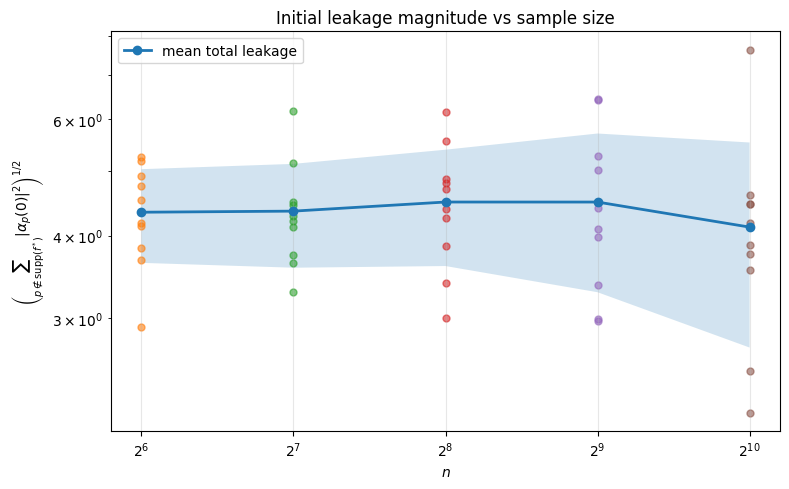

In [46]:
plt.figure(figsize=(8, 5))

ns = leak_stats["ns"]
mean = leak_stats["total_mean"]
std = leak_stats["total_std"]

plt.plot(ns, mean, marker="o", linewidth=2, label="mean total leakage")
plt.fill_between(ns, np.maximum(mean - std, 1e-16), mean + std, alpha=0.2)

for i, n in enumerate(ns):
    vals = leak_stats["raw_total"][i]
    plt.scatter(np.full_like(vals, n, dtype=float), vals, s=25, alpha=0.6)

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel(r"$n$")
plt.ylabel(r"$\left(\sum_{p\notin \mathrm{supp}(f^*)} |\alpha_p(0)|^2\right)^{1/2}$")
plt.title("Initial leakage magnitude vs sample size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
LEAKAGE_TRACK_MODES = ["cos_4", "cos_5", "cos_6"]
selected_leak = [m for m in LEAKAGE_TRACK_MODES if m in name_to_idx]

leak_decay_summary = {mode: aggregate_mode_decay(by_n, mode) for mode in selected_leak}

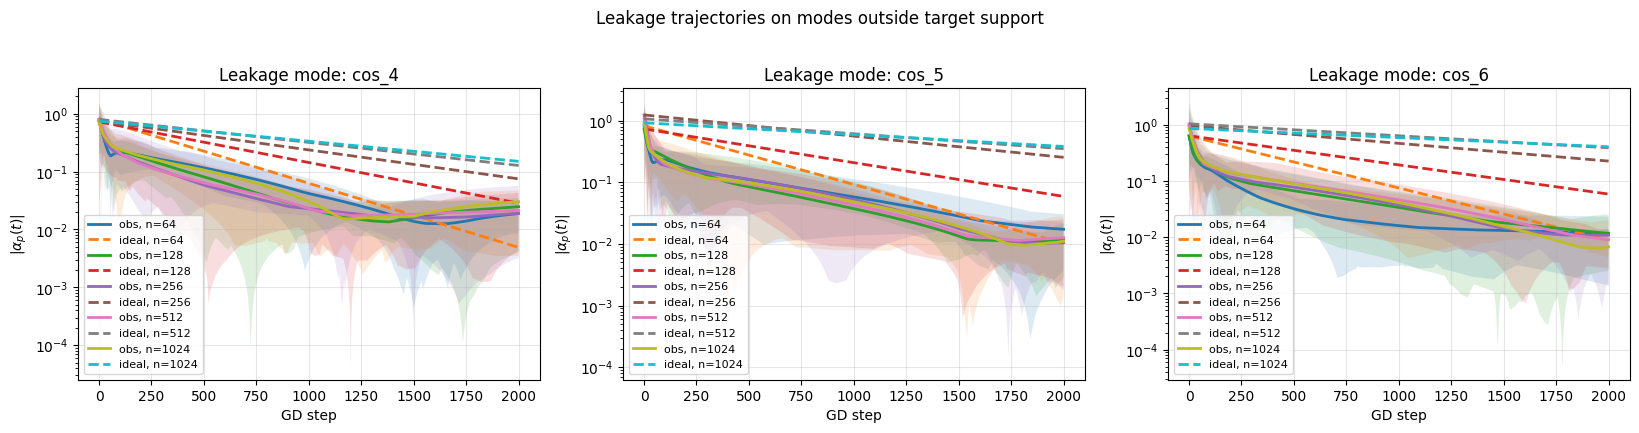

In [48]:
ncols = len(selected_leak)
fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4.2), squeeze=False)
axes = axes.ravel()

for ax, mode_name in zip(axes, selected_leak):
    summary = leak_decay_summary[mode_name]

    for n in sorted(summary.keys()):
        d = summary[n]
        steps = d["steps"]

        obs_mean = np.maximum(d["obs_mean"], EPS)
        obs_lo = np.maximum(d["obs_p10"], EPS)
        obs_hi = np.maximum(d["obs_p90"], EPS)
        ideal_mean = np.maximum(d["ideal_mean"], EPS)

        ax.plot(steps, obs_mean, linewidth=2, label=f"obs, n={n}")
        ax.fill_between(steps, obs_lo, obs_hi, alpha=0.15)
        ax.plot(steps, ideal_mean, "--", linewidth=2, label=f"ideal, n={n}")

    ax.set_yscale("log")
    ax.set_xlabel("GD step")
    ax.set_ylabel(r"$|\alpha_p(t)|$")
    ax.set_title(f"Leakage mode: {mode_name}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Leakage trajectories on modes outside target support", y=1.02)
plt.tight_layout()
plt.show()

## Why do the “ideal” decay rates still differ across $n$ even when $\eta$ is fixed?

The key point is that the plotted “ideal” curve is **not**
$$
\alpha_p^{\mathrm{ideal}}(t)=\alpha_p(0)\,(1-\eta \lambda_p)^t,
$$
with the same continuum eigenvalue $\lambda_p$ for every $n$.

Instead, the plotted finite-sample reference is
$$
\alpha_{p,n}^{\mathrm{ideal}}(t)
=
\alpha_{p,n}(0)\,\bigl(1-\eta\,\lambda_p^{(n)}\bigr)^t,
$$
where
$$
\lambda_p^{(n)}
=
\left(1-\frac{1}{n}\right)\lambda_p+\frac{1}{n}g(0).
$$

So even if $\eta$ is fixed, the decay rate still depends on $n$ through $\lambda_p^{(n)}$.

### What determines the slope on the log plot?

If we plot $|\alpha_{p,n}^{\mathrm{ideal}}(t)|$ on a log scale, the per-step slope is
$$
\log \bigl|1-\eta \lambda_p^{(n)}\bigr|.
$$

For small $\eta \lambda_p^{(n)}$, we have the approximation
$$
\log(1-\eta \lambda_p^{(n)}) \approx -\eta \lambda_p^{(n)}.
$$

So the decay rate is controlled directly by $\lambda_p^{(n)}$.

That is the mathematical reason the ideal slopes still differ across $n$ even after fixing $\eta$.

### Why is the $n$-dependence much stronger for higher modes?

Because the continuum eigenvalues $\lambda_p$ get smaller as the frequency increases, while the correction term
$$
\frac{1}{n}g(0)
$$
does **not** depend on the mode.

So the relative size of the correction is roughly
$$
\frac{\lambda_p^{(n)}-\lambda_p}{\lambda_p}
=
\frac{g(0)-\lambda_p}{n\lambda_p}
\approx
\frac{g(0)}{n\lambda_p}
\qquad \text{when } \lambda_p \text{ is small.}
$$

This means:

- for large low-mode eigenvalues, the correction is relatively small,
- for tiny higher-mode eigenvalues, the correction can be large in relative terms.

So this effect is not surprising. It is exactly what the finite-$n$ formula predicts.

## Comparing ideal and empirical eigenvalues / decay rates

There are two related but distinct spectral comparisons we want to make.

### 1. Global operator spectrum

The empirical operator is
$$
A = \frac{1}{n}K.
$$

Its eigenvalues are the actual empirical spectrum of the sampled kernel operator.  
For the low-frequency Fourier analysis, the finite-$n$ benchmark is
$$
\lambda_p^{(n)}
=
\left(1-\frac{1}{n}\right)\lambda_p+\frac{1}{n}g(0),
$$
where $\lambda_p$ is the continuum eigenvalue associated with the corresponding Fourier mode.

So one natural comparison is:

- empirical eigenvalues of $A$,
- versus the benchmark eigenvalues $\lambda_p^{(n)}$ for the Fourier block.

This tells us whether the sampled operator has roughly the expected low-frequency spectrum.

### 2. Per-mode empirical eigenvalue proxy

Since the sampled Fourier modes are only approximate empirical eigenvectors, a more mode-aligned quantity is the Rayleigh quotient
$$
\widehat{\lambda}_p^{\mathrm{emp}}
=
\frac{\phi_p^\top A \phi_p}{\phi_p^\top \phi_p}.
$$

This is the empirical eigenvalue that mode $\phi_p$ would see if it were an exact eigenvector.

The ideal benchmark for this same mode is $\lambda_p^{(n)}$.

So another natural comparison is:

- $\widehat{\lambda}_p^{\mathrm{emp}}$,
- versus $\lambda_p^{(n)}$.

This is often the most interpretable per-mode spectral comparison.

### 3. Ideal versus empirical decay rates

For a scalar diagonal mode, the ideal update factor is
$$
\rho_p^{\mathrm{ideal}} = 1-\eta \lambda_p^{(n)}.
$$

Using the empirical modal eigenvalue proxy, the corresponding empirical rate proxy is
$$
\rho_p^{\mathrm{emp}} = 1-\eta \widehat{\lambda}_p^{\mathrm{emp}}.
$$

These are not observed residual coefficients themselves; they are **predicted one-step contraction factors** implied by the benchmark and the empirical operator action on each sampled mode.

Comparing them helps us answer:

> Is the mismatch in mode decay mainly because the empirical operator has the wrong effective eigenvalue, or because the modes are not perfectly decoupled?

In [49]:
def decode_mode_names(arr):
    out = []
    for x in arr:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return out

def empirical_modal_eigenvalue_proxy(run):
    """
    Per-mode empirical eigenvalue proxy:
        lambda_hat_p = <phi_p, A phi_p> / <phi_p, phi_p>
                     = H_pp / G_pp
    """
    G = np.asarray(run["G"], dtype=float)
    H = np.asarray(run["H"], dtype=float)
    return np.diag(H) / np.diag(G)

def finite_n_benchmark_from_run(run):
    return np.asarray(run["Lambda_n_diag"], dtype=float)

def top_empirical_operator_eigs(run, top_k=None):
    A = np.asarray(run["A"], dtype=float)
    evals = np.linalg.eigvalsh(A)[::-1]
    if top_k is not None:
        evals = evals[:top_k]
    return evals

def expanded_benchmark_sorted(run):
    lam = np.asarray(run["Lambda_n_diag"], dtype=float)
    return np.sort(lam)[::-1]

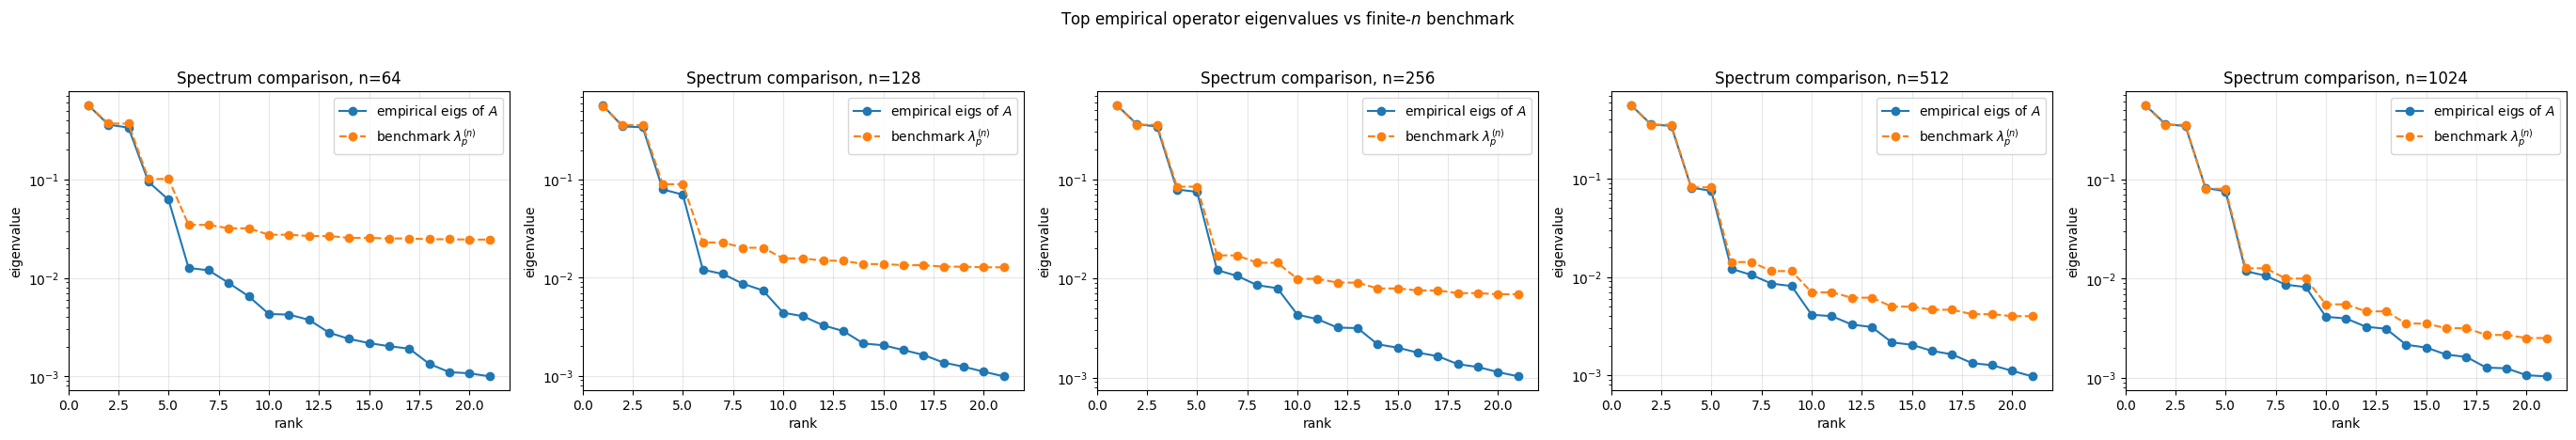

In [50]:
REP_NS = sorted(by_n.keys())  # or choose a subset like [64, 256, 1024]
REP_SEED = by_n[REP_NS[0]][0]["seed"]  # use same seed where possible

def get_run_by_seed(runs_n, seed):
    for r in runs_n:
        if r["seed"] == seed:
            return r
    return runs_n[0]

fig, axes = plt.subplots(1, len(REP_NS), figsize=(5.5 * len(REP_NS), 4.5), squeeze=False)
axes = axes.ravel()

for ax, n in zip(axes, REP_NS):
    run = get_run_by_seed(by_n[n], REP_SEED)

    lam_emp = top_empirical_operator_eigs(run, top_k=len(run["Lambda_n_diag"]))
    lam_bench = expanded_benchmark_sorted(run)

    k = np.arange(1, len(lam_bench) + 1)

    ax.plot(k, lam_emp, marker="o", label="empirical eigs of $A$")
    ax.plot(k, lam_bench, marker="o", linestyle="--", label=r"benchmark $\lambda_p^{(n)}$")

    ax.set_yscale("log")
    ax.set_xlabel("rank")
    ax.set_ylabel("eigenvalue")
    ax.set_title(f"Spectrum comparison, n={n}")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.suptitle("Top empirical operator eigenvalues vs finite-$n$ benchmark", y=1.03)
plt.tight_layout()
plt.show()

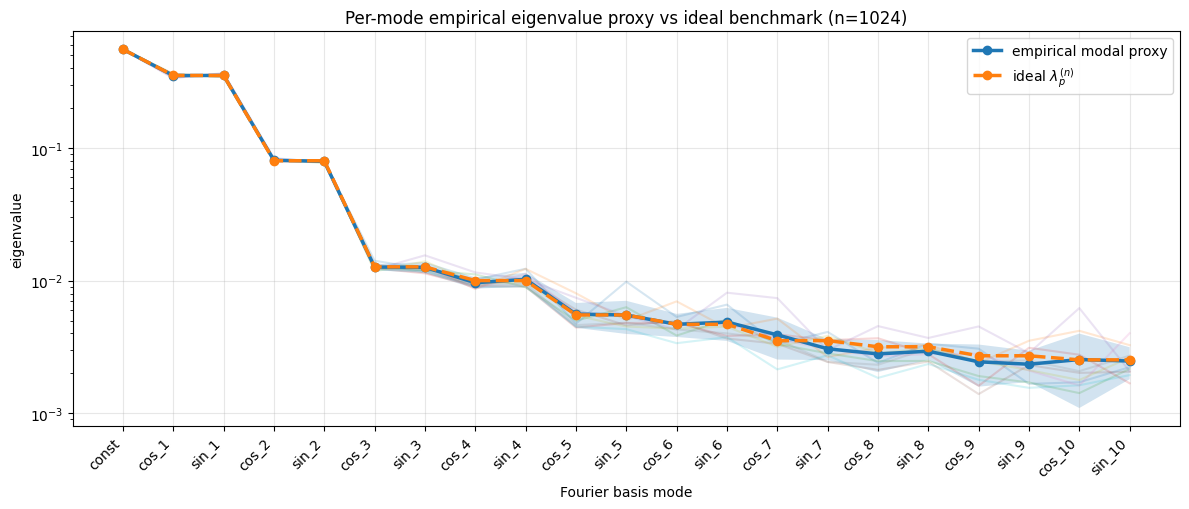

In [53]:
REP_N = max(by_n.keys())  # or choose 256 / 512 / 1024
runs_rep = by_n[REP_N]

mode_names = decode_mode_names(runs_rep[0]["mode_names"])
x = np.arange(len(mode_names))

per_seed_emp = np.stack([empirical_modal_eigenvalue_proxy(r) for r in runs_rep], axis=0)
per_seed_ideal = np.stack([finite_n_benchmark_from_run(r) for r in runs_rep], axis=0)

emp_mean = per_seed_emp.mean(axis=0)
emp_std = per_seed_emp.std(axis=0)

ideal_mean = per_seed_ideal.mean(axis=0)
ideal_std = per_seed_ideal.std(axis=0)

plt.figure(figsize=(12, 5.2))

for row in per_seed_emp:
    plt.plot(x, row, alpha=0.18)

plt.plot(x, emp_mean, marker="o", linewidth=2.5, label="empirical modal proxy")
plt.fill_between(
    x,
    emp_mean - emp_std,
    emp_mean + emp_std,
    alpha=0.2,
)

plt.plot(x, ideal_mean, marker="o", linestyle="--", linewidth=2.5, label=r"ideal $\lambda_p^{(n)}$")
plt.fill_between(
    x,
    ideal_mean - ideal_std,
    ideal_mean + ideal_std,
    alpha=0.15,
)

plt.yscale("log")
plt.xticks(x, mode_names, rotation=45, ha="right")
plt.xlabel("Fourier basis mode")
plt.ylabel("eigenvalue")
plt.title(f"Per-mode empirical eigenvalue proxy vs ideal benchmark (n={REP_N})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
print(f"=== Per-mode eigenvalue comparison for n = {REP_N} ===")
for name, e_m, e_s, i_m, i_s in zip(mode_names, emp_mean, emp_std, ideal_mean, ideal_std):
    print(
        f"{name:>8s}   "
        f"emp={e_m:.4e} ± {e_s:.2e}   "
        f"ideal={i_m:.4e} ± {i_s:.2e}"
    )

=== Per-mode eigenvalue comparison for n = 1024 ===
   const   emp=5.5490e-01 ± 3.46e-04   ideal=5.5489e-01 ± 0.00e+00
   cos_1   emp=3.5171e-01 ± 8.86e-03   ideal=3.5244e-01 ± 0.00e+00
   sin_1   emp=3.5274e-01 ± 8.32e-03   ideal=3.5244e-01 ± 0.00e+00
   cos_2   emp=8.0895e-02 ± 1.47e-03   ideal=8.0193e-02 ± 0.00e+00
   sin_2   emp=7.9357e-02 ± 1.36e-03   ideal=8.0193e-02 ± 0.00e+00
   cos_3   emp=1.2663e-02 ± 6.52e-04   ideal=1.2712e-02 ± 0.00e+00
   sin_3   emp=1.2608e-02 ± 1.22e-03   ideal=1.2712e-02 ± 0.00e+00
   cos_4   emp=9.6497e-03 ± 9.47e-04   ideal=1.0012e-02 ± 0.00e+00
   sin_4   emp=1.0242e-02 ± 1.22e-03   ideal=1.0012e-02 ± 0.00e+00
   cos_5   emp=5.5982e-03 ± 1.19e-03   ideal=5.5137e-03 ± 0.00e+00
   sin_5   emp=5.5059e-03 ± 1.54e-03   ideal=5.5137e-03 ± 0.00e+00
   cos_6   emp=4.6885e-03 ± 9.28e-04   ideal=4.6874e-03 ± 0.00e+00
   sin_6   emp=4.8729e-03 ± 1.36e-03   ideal=4.6874e-03 ± 0.00e+00
   cos_7   emp=3.9035e-03 ± 1.36e-03   ideal=3.5306e-03 ± 0.00e+00
   sin_7  

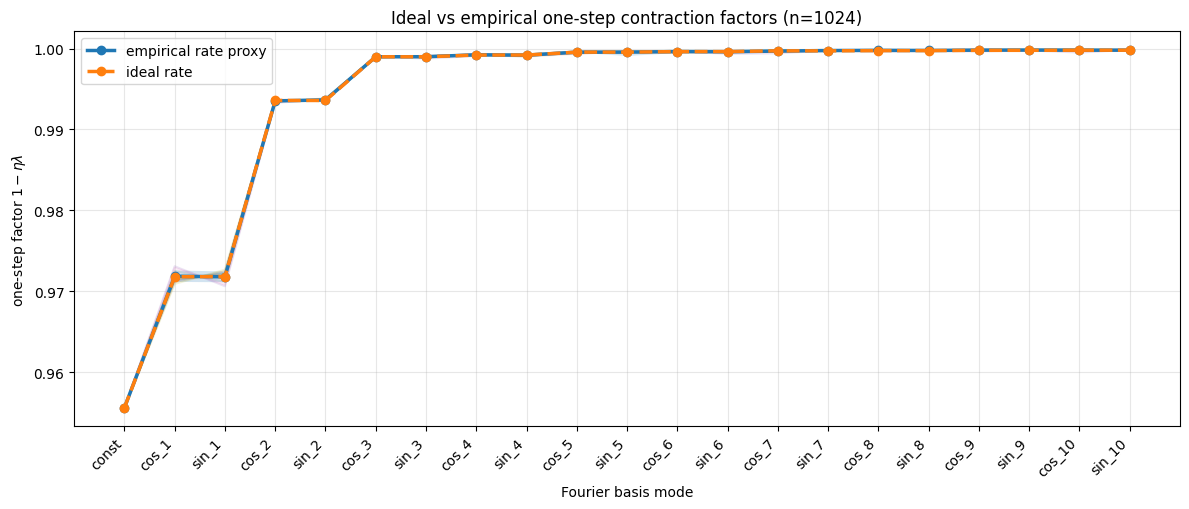

In [55]:
def empirical_modal_rate_proxy(run):
    lam_emp = empirical_modal_eigenvalue_proxy(run)
    eta = float(run["eta"])
    return 1.0 - eta * lam_emp

def ideal_modal_rate(run):
    lam_ideal = finite_n_benchmark_from_run(run)
    eta = float(run["eta"])
    return 1.0 - eta * lam_ideal

REP_N = max(by_n.keys())
runs_rep = by_n[REP_N]

per_seed_rate_emp = np.stack([empirical_modal_rate_proxy(r) for r in runs_rep], axis=0)
per_seed_rate_ideal = np.stack([ideal_modal_rate(r) for r in runs_rep], axis=0)

rate_emp_mean = per_seed_rate_emp.mean(axis=0)
rate_emp_std = per_seed_rate_emp.std(axis=0)

rate_ideal_mean = per_seed_rate_ideal.mean(axis=0)
rate_ideal_std = per_seed_rate_ideal.std(axis=0)

x = np.arange(len(mode_names))

plt.figure(figsize=(12, 5.2))

for row in per_seed_rate_emp:
    plt.plot(x, row, alpha=0.18)

plt.plot(x, rate_emp_mean, marker="o", linewidth=2.5, label="empirical rate proxy")
plt.fill_between(
    x,
    rate_emp_mean - rate_emp_std,
    rate_emp_mean + rate_emp_std,
    alpha=0.2,
)

plt.plot(x, rate_ideal_mean, marker="o", linestyle="--", linewidth=2.5, label="ideal rate")
plt.fill_between(
    x,
    rate_ideal_mean - rate_ideal_std,
    rate_ideal_mean + rate_ideal_std,
    alpha=0.15,
)

plt.xticks(x, mode_names, rotation=45, ha="right")
plt.xlabel("Fourier basis mode")
plt.ylabel(r"one-step factor $1-\eta \lambda$")
plt.title(f"Ideal vs empirical one-step contraction factors (n={REP_N})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Simple spectral comparison: continuum, finite-$n$, and empirical operator spectrum

To keep the comparison simple, we consider three spectra:

### 1. Continuum benchmark
These are the continuum Fourier eigenvalues
$$
\lambda_p,
$$
obtained from the analytic kernel on $S^1$.

We refer to these as the **ideal** eigenvalues.

### 2. Finite-sample corrected benchmark
These are the diagonal benchmark values
$$
\lambda_p^{(n)}
=
\left(1-\frac{1}{n}\right)\lambda_p+\frac{1}{n}g(0),
$$
which arise from the finite-sample correction in the compressed operator calculation.

They can be viewed as the finite-$n$ prediction for the low-frequency Fourier block.

### 3. Empirical spectrum
These are the actual eigenvalues of the sampled empirical operator
$$
A=\frac{1}{n}K.
$$

Since the empirical eigenvectors are not exactly the Fourier basis vectors, this is not a mode-by-mode comparison. Instead, it is a **sorted spectrum comparison**:
- sort the continuum block eigenvalues,
- sort the finite-$n$ corrected eigenvalues,
- sort the empirical eigenvalues of $A$,
and compare them by rank.

## Decay-rate comparison

Given a fixed step size $\eta$, each eigenvalue $\lambda$ induces a one-step contraction factor
$$
\rho = 1-\eta\lambda.
$$

So we compare three corresponding decay-rate spectra:

- continuum rates:
  $$
  \rho_p^{\mathrm{cont}} = 1-\eta\lambda_p,
  $$
- finite-$n$ rates:
  $$
  \rho_p^{(n)} = 1-\eta\lambda_p^{(n)},
  $$
- empirical rates:
  $$
  \rho_j^{\mathrm{emp}} = 1-\eta\mu_j,
  $$
  where $\mu_j$ are the empirical eigenvalues of $A$.

This gives a simple way to see:
- how far the finite-$n$ correction moves the continuum benchmark,
- and how close the actual empirical operator spectrum is to these predictions.

etas in this group: [0.08 0.08 0.08 0.08 0.08 0.08 0.08 0.08 0.08 0.08]
Using eta = 0.08


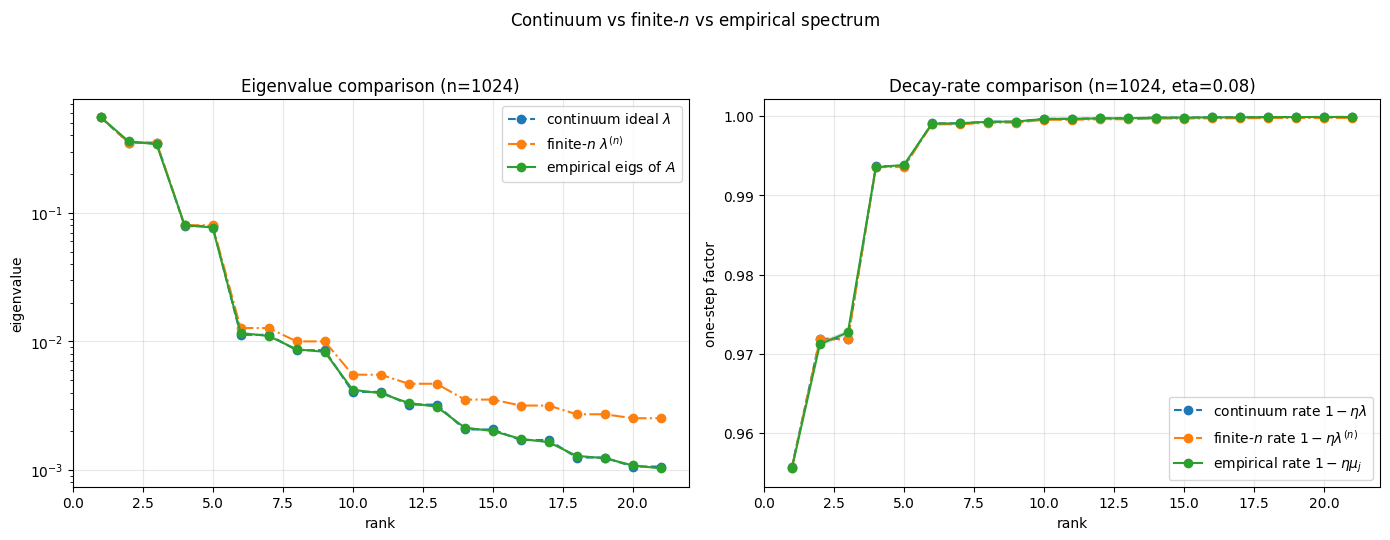

In [56]:
from core.kernel_analysis import continuum_fourier_eigenvalues_bias

REP_N = max(by_n.keys())   # or choose e.g. 256, 512, 1024
runs_rep = by_n[REP_N]

mode_freqs = np.asarray(runs_rep[0]["mode_freqs"], dtype=int)
d = len(mode_freqs)

# constant-eta rerun assumed
etas = np.array([r["eta"] for r in runs_rep], dtype=float)
print("etas in this group:", etas)
eta = float(np.median(etas))
print("Using eta =", eta)

# Continuum eigenvalues lambda_p expanded to the Fourier block
kmax = int(mode_freqs.max())
lambda_by_k = np.asarray(continuum_fourier_eigenvalues_bias(np.arange(kmax + 1)), dtype=float)
lambda_cont_block = lambda_by_k[mode_freqs]

# Finite-n benchmark lambda_p^(n)
lambda_finite_block = np.asarray(runs_rep[0]["Lambda_n_diag"], dtype=float)

# Sorted benchmark spectra
lambda_cont_sorted = np.sort(lambda_cont_block)[::-1]
lambda_finite_sorted = np.sort(lambda_finite_block)[::-1]

# Empirical eigenvalues of A, aggregated across seeds
emp_eigs_all = []
for r in runs_rep:
    A_mat = np.asarray(r["A"], dtype=float)
    eigs = np.linalg.eigvalsh(A_mat)[::-1][:d]
    emp_eigs_all.append(eigs)
emp_eigs_all = np.stack(emp_eigs_all, axis=0)

emp_eigs_mean = emp_eigs_all.mean(axis=0)
emp_eigs_std = emp_eigs_all.std(axis=0)

# Corresponding decay factors rho = 1 - eta lambda
rho_cont = 1.0 - eta * lambda_cont_sorted
rho_finite = 1.0 - eta * lambda_finite_sorted
rho_emp_mean = 1.0 - eta * emp_eigs_mean
rho_emp_std = eta * emp_eigs_std  # propagated linearly

ranks = np.arange(1, d + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

# --- Eigenvalues ---
ax = axes[0]
ax.plot(ranks, lambda_cont_sorted, marker="o", linestyle="--", label=r"continuum ideal $\lambda$")
ax.plot(ranks, lambda_finite_sorted, marker="o", linestyle="-.", label=r"finite-$n$ $\lambda^{(n)}$")
ax.plot(ranks, emp_eigs_mean, marker="o", label=r"empirical eigs of $A$")
ax.fill_between(
    ranks,
    np.maximum(emp_eigs_mean - emp_eigs_std, 1e-16),
    emp_eigs_mean + emp_eigs_std,
    alpha=0.2,
)
ax.set_yscale("log")
ax.set_xlabel("rank")
ax.set_ylabel("eigenvalue")
ax.set_title(f"Eigenvalue comparison (n={REP_N})")
ax.grid(True, alpha=0.3)
ax.legend()

# --- Decay rates ---
ax = axes[1]
ax.plot(ranks, rho_cont, marker="o", linestyle="--", label=r"continuum rate $1-\eta\lambda$")
ax.plot(ranks, rho_finite, marker="o", linestyle="-.", label=r"finite-$n$ rate $1-\eta\lambda^{(n)}$")
ax.plot(ranks, rho_emp_mean, marker="o", label=r"empirical rate $1-\eta\mu_j$")
ax.fill_between(
    ranks,
    rho_emp_mean - rho_emp_std,
    rho_emp_mean + rho_emp_std,
    alpha=0.2,
)
ax.set_xlabel("rank")
ax.set_ylabel(r"one-step factor")
ax.set_title(f"Decay-rate comparison (n={REP_N}, eta={eta:.4g})")
ax.grid(True, alpha=0.3)
ax.legend()

plt.suptitle("Continuum vs finite-$n$ vs empirical spectrum", y=1.03)
plt.tight_layout()
plt.show()